# Exploring the Data Lake

**Three zoom levels:**

| Level | Question | Tool | Cost |
|---|---|---|---|
| **Storage** | What files physically exist? | `s3_ls()` (boto3) | free |
| **Catalog** | What's registered as a queryable table? | `databases()`, `tables()`, `describe()` (Glue) | free |
| **Data** | What do the values look like? | `aq()` (Athena) or `dread()` (DuckDB) | small / local |

Note: If anything says *"token expired"*, run `aws sso login --profile ciccada` in a terminal and re-run the cell.

In [1]:
from aws_config import *
# confirm you're logged in
# if not, run "aws sso login --profile ciccada" in your terminal and try again
session.client('sts').get_caller_identity()['Arn']

'arn:aws:sts::130340360668:assumed-role/AWSReservedSSO_AWSAdministratorAccess_58ece215f84a4b54/z3553082_sa@ad.unsw.edu.au'

## Imports & declarations

In [2]:
import pandas as pd
# Show every single column
pd.set_option('display.max_columns', None)

## [Level 1] Storage: the physical files in S3

`s3_ls()` lists what's actually in the bucket. 

This is ground truth. Works even for data that isn't in Glue yet.

In [3]:
# Top level of the bucket. Major data areas
s3_ls()

,type,name,size_mb
0,folder,BOM_NCI/,None
1,folder,DeepArchive/,None
2,folder,Flask_App/,None
3,folder,PostgreJDBC_Driver/,None
4,folder,SAPN/,None
5,folder,SAPNTest/,None
6,folder,Trino-Warehouse/,None
7,folder,athena-results/,None
8,folder,spark-warehouse/,None
9,folder,temp_SolA/,None


In [4]:
# Inside the Spark warehouse is where results tables seem to be written
s3_ls('spark-warehouse/')

,type,name,size_mb
0,folder,spark-warehouse/Compliance_results_SolA/,None
1,folder,spark-warehouse/SolA_metadata/,None
2,folder,spark-warehouse/bucketed_table4_partitions_loo...,None


In [5]:
# Drill into one table's folder to see its partitioning.
# Partition folders look like year=2025/month=1/
# This is what makes `WHERE year=2025 AND month=1` cheap (Athena reads only those folders).
s3_ls('Trino-Warehouse/')

,type,name,size_mb
0,folder,Trino-Warehouse/BOM_NCI/,None
1,folder,Trino-Warehouse/SAPN2022/,None
2,folder,Trino-Warehouse/solar_analytics/,None


## [Level 2] Catalog: what's queryable, and its schema

Glue is the index that lets us write SQL. These calls are (metadata only).

In [6]:
databases()

,Database,Description
0,bom_nci,
1,default,Default Hive database
2,elb_logdb,
3,sapn2022,
4,solar_analytics,Migrated from Hive Metastore
5,solar_analytics_iceberg,
6,test_db,
7,type_probe,


In [7]:
# Every table in every database, in one view.
all_tabs = pd.concat([tables(d) for d in databases()['Database']], ignore_index=True)
all_tabs[['Database', 'Table']]

,Database,Table
0,bom_nci,solar
1,elb_logdb,elb_logs_tbl
2,sapn2022,circuit_measurements
3,sapn2022,circuit_measurements_curtailment_train
4,solar_analytics,circuits
5,solar_analytics,compliance_voltvar
6,solar_analytics,compliance_voltwatt
7,solar_analytics,meta_single_inverters
8,solar_analytics,meta_single_inverters_wrong_capacity
9,solar_analytics,meta_single_inverters_wrong_capacity_up2_3c


In [8]:
# The columns + types of any table. 
# Works for Iceberg tables too (where the # Glue column list is often blank). 
# Kind of 'data dictionary' lookup.
table = "conformance_antiisland"
database = "solar_analytics_iceberg"
aq(f"SELECT * FROM {table} LIMIT 5", database=database)

,year,month,day,day_night,site_id,nonconformance_antiisland_sum,nonconformance_antiisland_count,total_count,v_threshold
0,2025,6,3,day,1265091456,50.812484,11,11,265.0
1,2025,6,4,day,1265091456,93.838198,21,21,265.0
2,2025,6,5,day,1265091456,113.066314,26,26,265.0
3,2025,6,8,day,1265091456,31.670982,6,6,265.0
4,2025,6,9,day,1265091456,105.840652,24,24,265.0


## [Level 3] Data peek at actual rows

Two engines, same files. 

1. Use `aq()` (Athena) for normal SQL
2. use `dread()` (DuckDB, reads the Parquet file directly) for quick peeks or when Glue's description is wrong.

**Cost:** on the big `ts` table, always filter on `year`/`month`/`is_pv` and never sort on a fresh peek.

In [9]:
# Dimension tables are tiny
aq('SELECT * FROM circuits LIMIT 5')

,site_id,device_id,circuit_id,device_type,circuit_polarity,circuit_type,is_pv
0,484720983,135961,84703,Watt Watcher,1,pv_site_net,True
1,150652475,140483,658777,Watt Watcher,1,ac_load_net,False
2,150652475,140483,658778,Watt Watcher,1,ac_load_net,False
3,484720983,135961,84704,Watt Watcher,1,pv_site_net,True
4,484720983,135961,84705,Watt Watcher,1,pv_site_net,True


In [10]:
# The telemetry fact table: a CHEAP peek (no ORDER BY, just LIMIT).
# This shows the real column names so we can write proper filtered queries next.
aq('SELECT * FROM ts LIMIT 5', database='solar_analytics_iceberg')

,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv,postcode
0,234491,2025-01-19 19:35:00,51.7900,4.3158,0.1489,4.3158,0.0000,0.1489,0.0000,0.998811,240.30,0.2830,2025,1,True,2756
1,234491,2025-01-20 03:10:00,1702.0767,141.8397,2.4139,141.8397,0.0000,2.4139,0.0000,0.999710,241.80,7.0400,2025,1,True,2756
2,256581,2025-01-01 02:30:00,-1126.2767,-93.8564,-158.4025,0.0000,93.8564,0.0000,158.4025,0.259850,246.70,8.9670,2025,1,True,5354
3,256581,2025-01-01 07:30:00,-761.5833,-63.4653,-103.5872,0.0000,63.4653,0.0000,103.5872,0.272923,237.05,5.8955,2025,1,True,5354
4,256581,2025-01-02 01:10:00,-920.1833,-76.6819,-130.4661,0.0000,76.6819,0.0000,130.4661,0.256757,245.55,7.3965,2025,1,True,5354


In [11]:
# How many rows in one month of PV telemetry? (count scans only the partition)
aq('''
    SELECT count(*) AS rows
    FROM ts
    WHERE is_pv = True AND year = 2025 AND month = 1
''', database='solar_analytics_iceberg')

,rows
0,352512834


## If Athena chokes: read the Parquet directly with DuckDB

Some results tables have *schema drift*. The Glue description disagrees with the file (e.g. a column the file stores as integer but Glue calls a double). This is common.

Athena won't be able to read it, so DuckDB reads the file's own schema and just works.

The S3 path comes from the error message, or from `s3_ls()`.

In [12]:
dread('s3://project-ciccada/spark-warehouse/'
      'Compliance_results_SolA/compliance_voltvar.parquet/*.parquet')

,year,month,day,site_id,s_id,day_night,noncompliance_voltvar_count,noncompliance_voltvar_sum,Q_adverse,Q_inactive,Q_minor,Q_major,Q_benevolent,total_count,Q_adverse_count,Q_inactive_count,Q_minor_count,Q_major_count,Q_benevolent_count
0,2024,5,9,788279632,S5799,night,14,4.399978,0.000000,0.00000,0.0,0.046533,4.353445,180,0,0,0,1,13
1,2024,5,23,1997359488,S14761,day,0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,108,0,0,0,0,0
2,2024,5,29,4707527,S37,night,24,2.433597,2.433597,0.00000,0.0,0.000000,0.000000,180,24,0,0,0,0
3,2024,5,9,14711880,S117,night,1,0.001990,0.000000,0.00199,0.0,0.000000,0.000000,180,0,1,0,0,0
4,2024,5,3,17282833,S135,night,0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,180,0,0,0,0,0


## Recipe to explore any new data source in future

1. **`s3_ls('<prefix>/')`**: See what physically exists and how it's "foldered".
2. **`databases()` / `tables(db)`**: Check if it is registered in Glue. If yes, can use SQL.
3. **`describe('<table>', db)`**: Learn its columns.
4. **`aq('SELECT ... LIMIT 5')`**: Peek at values (filter on partitions if it's big).
5. Note: Not in Glue, or Glue is wrong?: Point **`dread('s3://.../*.parquet')`** straight at the files.

# Exploratory Data Analysis - Solar Analytics

In [13]:
# =============================================================================
# Exploratory Data Analysis Solar Analytics
# Goal: understand the time range, site/circuit counts, and data shape before touching the analysis notebooks.
# =============================================================================

# Short aliases for the two databases we'll use constantly
SA  = "solar_analytics"
SAI = "solar_analytics_iceberg"

## Sites and circuits

In [14]:
# -----------------------------------------------------------------------------
#
# Assumptions:
# sites  = physical locations (one row per address)
# circuits = monitoring points within a site (one row per phase/device)
# is_pv = True means it's a solar PV circuit (not load, battery, etc.)
# -----------------------------------------------------------------------------

site_count = aq("SELECT count(*) AS n_sites FROM sites", database=SAI)
print("Total sites:", site_count["n_sites"].iloc[0])

Total sites: 41393


In [15]:
circuit_counts = aq("""
    SELECT
        is_pv,
        count(*)          AS n_circuits,
        count(DISTINCT site_id) AS n_sites
    FROM circuits
    GROUP BY is_pv
    ORDER BY is_pv DESC
""", 
database=SAI)
circuit_counts

# is_pv=True rows are what the telemetry analysis is built on.
# is_pv=False rows are load / battery / EV circuits at the same sites.
# The values below double count sites because many sites have both PV and non-PV circuits.

,is_pv,n_circuits,n_sites
0,True,79686,39733
1,False,91725,38191


In [16]:
# How many circuits per site?
circuits_per_site = aq("""
    SELECT
        circuit_count,
        count(*) AS n_sites
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY circuit_count
    ORDER BY circuit_count
""", database=SAI)
circuits_per_site

,circuit_count,n_sites
0,1,22454
1,2,3527
2,3,11556
3,4,432
4,5,51
5,6,1195
6,7,22
7,8,11
8,9,224
9,10,7


## Geo spread

In [17]:
# -----------------------------------------------------------------------------
# Geographic spread — use meta_up23c, not sites
# -----------------------------------------------------------------------------

states = aq("""
    SELECT state, count(*) AS n_sites
    FROM meta_up23c
    GROUP BY state
    ORDER BY n_sites DESC
""", database=SAI)
states

,state,n_sites
0,NSW,26676
1,QLD,18276
2,VIC,5741
3,SA,4917
4,WA,2452
5,TAS,1086
6,ACT,944
7,NT,478


In [18]:
# -----------------------------------------------------------------------------
# Use partition_lookup (tiny table) rather than querying ts directly.
# Reading min/max timestamps from a billions-row table is expensive;
# the lookup table gives you the answer for free.
# -----------------------------------------------------------------------------

partitions = aq("SELECT * FROM partition_lookup ORDER BY year, month", database=SA)
partitions
# Each row = one (year, month) partition that exists in the ts table.
# The first and last rows tell you the data window.

,year,month,is_pv
0,2024,1,False
1,2024,1,True
2,2024,2,False
3,2024,2,True
4,2024,3,False
5,2024,3,True
6,2024,4,True
7,2024,4,False
8,2024,5,True
9,2024,5,False


In [19]:
unique_months = partitions[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])

print("Data covers:")
print(f"  From: {unique_months['year'].iloc[0]}-{str(unique_months['month'].iloc[0]).zfill(2)}")
print(f"  To:   {unique_months['year'].iloc[-1]}-{str(unique_months['month'].iloc[-1]).zfill(2)}")
print(f"  Total months: {len(unique_months)}")

Data covers:
  From: 2024-01
  To:   2025-06
  Total months: 18


## Schema of the key tables

In [20]:
# Schema discovery for all Iceberg tables
# DESCRIBE doesn't work for Iceberg via Glue.
# Column names come back as DataFrame headers from SELECT * LIMIT 1.

iceberg_tables = [
    "ts", "circuits", "sites", "conformance_voltwatt",
    "conformance_voltvar", "conformance_antiisland",
    "conformance_sust_op", "all_uncurtailedpv", "meta_up23c"
]

schemas = {}
for t in iceberg_tables:
    try:
        row = aq(f"SELECT * FROM {t} LIMIT 1", database=SAI)
        schemas[t] = pd.DataFrame({
            "column": row.columns.tolist(),
            "dtype":  [str(d) for d in row.dtypes.tolist()]
        })
        print(f"✓ {t:35s} {len(row.columns)} columns")
    except Exception as e:
        print(f"✗ {t:35s} ERROR: {e}")

✓ ts                                  16 columns
✓ circuits                            4 columns
✓ sites                               3 columns
✓ conformance_voltwatt                8 columns
✓ conformance_voltvar                 23 columns
✓ conformance_antiisland              9 columns
✓ conformance_sust_op                 9 columns
✓ all_uncurtailedpv                   8 columns
✓ meta_up23c                          38 columns


In [21]:
# Open up schemas here:
schemas['ts']

,column,dtype
0,circuit_id,Int64
1,t_stamp,datetime64[us]
2,power,float64
3,energy,float64
4,energy_reactive,float64
5,energy_import,float64
6,energy_export,float64
7,energy_reactive_import,float64
8,energy_reactive_export,float64
9,power_factor,float64


In [22]:
# Open up schemas here:
schemas['conformance_voltwatt']

,column,dtype
0,year,Int64
1,month,Int64
2,day,Int64
3,site_id,Int64
4,p_kw_sum,float64
5,nonconformance_voltwatt_sum,float64
6,nonconformance_voltwatt_count,Int64
7,total_count,Int64


In [23]:
# Open up schemas here:
schemas['conformance_antiisland']

,column,dtype
0,year,Int32
1,month,Int32
2,day,Int32
3,day_night,string
4,site_id,Int64
5,nonconformance_antiisland_sum,float64
6,nonconformance_antiisland_count,Int64
7,total_count,Int64
8,v_threshold,float64


In [24]:
# Open up schemas here:
schemas['conformance_sust_op']

,column,dtype
0,year,Int32
1,month,Int32
2,day,Int32
3,day_night,string
4,site_id,Int64
5,nonconformance_sust_op_sum,float64
6,nonconformance_sust_op_count,Int64
7,total_count,Int64
8,v_threshold,float64


In [25]:
# =============================================================================
# The metadata table is meta_up23c, not sites
# sites (Iceberg) only has 3 columns; all rich metadata is in meta_up23c
# =============================================================================

print("meta_up23c columns:")
print(schemas["meta_up23c"]["column"].tolist())

meta_up23c columns:
['site_id', 'state', 'postcode', 'longitude', 'latitude', 'dnsp_name', 'dc_capacity_kw', 'ac_capacity_kw', 'export_limit_kw', 'monitoring_start', 'inverter_count', 'pv_install_date', 'manufacturer', 'model', 'ac_capacity_kw_json', 'device_id', 'circuit_id', 'device_type', 'circuit_polarity', 'circuit_type', 'is_pv', 'min_time', 'max_time', 'v_95', 'v_05', 'v_99', 'v_01', 'voltage_class', 'm_id', 'avg_pf', 'std_pf', 'pf_99', 'pf_01', 'n_long', 'n_lat', 'distance_km', 's_99', 'flex_export_detected']


In [26]:
# Circuit count banded: makes the 1-to-60 range interpretable
circuit_profile = aq("""
    SELECT
        CASE
            WHEN circuit_count = 1  THEN '1  - single phase'
            WHEN circuit_count = 2  THEN '2  - split or data gap'
            WHEN circuit_count = 3  THEN '3  - three phase'
            WHEN circuit_count <= 6 THEN '4-6 - multi-array or battery'
            ELSE                         '7+  - commercial / large site'
        END AS circuit_profile,
        count(*) AS n_sites,
        round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY 1
    ORDER BY min(circuit_count)
""", database=SAI)
circuit_profile

,circuit_profile,n_sites,pct
0,1 - single phase,22454,56.5
1,2 - split or data gap,3527,8.9
2,3 - three phase,11556,29.1
3,4-6 - multi-array or battery,1678,4.2
4,7+ - commercial / large site,518,1.3


In [27]:
meta_count = aq("""
    SELECT count(*) AS n_sites,
           count(DISTINCT state) AS n_states
    FROM meta_single_inverters
""", database=SA)
meta_count

,n_sites,n_states
0,37491,8


## Fleet characteristics

In [28]:
# -----------------------------------------------------------------------------
# Site summary four separate queries, one per count
# (Athena can't mix two databases in a single query)
# -----------------------------------------------------------------------------

n_sites         = aq("SELECT count(DISTINCT site_id) AS n FROM sites",       database=SAI)["n"].iloc[0]
n_meta_up23c    = aq("SELECT count(DISTINCT site_id) AS n FROM meta_up23c",  database=SAI)["n"].iloc[0]
n_pv_circuits   = aq("SELECT count(DISTINCT site_id) AS n FROM circuits WHERE is_pv = True", database=SAI)["n"].iloc[0]
n_single_inv    = aq("SELECT count(*) AS n FROM meta_single_inverters",       database=SA) ["n"].iloc[0]

site_summary = pd.DataFrame([{
    "total_in_sites_table":       n_sites,
    "sites_in_meta_up23c":        n_meta_up23c,
    "sites_with_pv_circuit":      n_pv_circuits,
    "meta_single_inverters_rows": n_single_inv,
}])
site_summary

,total_in_sites_table,sites_in_meta_up23c,sites_with_pv_circuit,meta_single_inverters_rows
0,41393,16148,39733,37491


# Telemetry plots: one month, one circuit

In [29]:
# =============================================================================
# Telemetry explorer. Single site, one month, voltage + generation plot
#
# KEY CONCEPT: Select by SITE, not circuit.
#   - site_id  = the physical address (one row in meta_up23c)
#   - circuit_id = one monitoring channel per phase
#   - The conformance results are per site_id, so site is the selector.
#   - Then look up the circuit_id(s) for that site to pull raw telemetry.
# =============================================================================

## Definitions

In [62]:
# AS/NZS 4777.2:2020 Australia-A set-points + pipeline constants
AS4777 = {
    # Volt-Watt: 100% S_rated at/below V1, ramp to 20% at V2
    "VW":   {"V1": 253.0, "V2": 260.0, "P1": 1.00, "P2": 0.20},

    # Volt-VAr: +Q1 supplying <=V1, 0 across deadband V2..V3, -Q4 absorbing >=V4
    "VVAR": {"V1": 207.0, "V2": 220.0, "V3": 240.0, "V4": 258.0,
             "Q1": 0.44, "Q4": 0.60},

    # Volt-VAr Q_impact category thresholds (signed measured/required ratio)
    "QIMP": {"thr1": -0.1, "thr2": 0.1, "thr3": 0.9, "thr4": 1.1},

    "TOL_FRAC":         0.04,   # +/-4% S_rated tolerance band, used everywhere
    "SITE_CONF_THRESH": 0.10,   # site conformant if nonconf fraction <= 10%
    "PV_ACTIVE_FRAC":   0.16,   # 'solar generating' = P_pv > 16% S_rated
    "INTERVAL_H":       5/60,   # 5-min interval -> hours, for kW-sum -> kWh

    # Sustained-operation: inverter must cease generating if V sustained
    # above this threshold for 3 consecutive 5-min intervals (~15 min).
    # Source: AS/NZS 4777.2:2020 
    "SUSTOP_V_CEIL":    258.0,
    "SUSTOP_V_BAND":    (253, 258),  # sweep range stored in conformance_sust_op*

    # Anti-islanding thresholdsAS/NZS 4777.2:2020
    # Under-voltage (UV): voltage too low, inverter must disconnect
    # These sit far below normal operating range; shown as annotation not axis lines for now
    "AI_UV2":  70.0,    # V ≤ 70 V  → disconnect in ≤ 2 s
    "AI_UV1": 180.0,    # V ≤ 180 V → disconnect in ≤ 11 s
    # Over-voltage (OV): 
    "AI_OV1": 265.0,    # V ≥ 265 V → disconnect in ≤ 2 s
    "AI_OV2": 275.0,    # V ≥ 275 V → disconnect in ≤ 0.2 s
    # Note: at 5-min telemetry resolution these sub-second trips are not directly observable

    "AI_V_BAND":        (260, 265),  # sweep range stored in conformance_antiisland
}

print("AS4777 constants loaded:")
for k, v in AS4777.items():
    print(f"  {k:20s} = {v}")

AS4777 constants loaded:
  VW                   = {'V1': 253.0, 'V2': 260.0, 'P1': 1.0, 'P2': 0.2}
  VVAR                 = {'V1': 207.0, 'V2': 220.0, 'V3': 240.0, 'V4': 258.0, 'Q1': 0.44, 'Q4': 0.6}
  QIMP                 = {'thr1': -0.1, 'thr2': 0.1, 'thr3': 0.9, 'thr4': 1.1}
  TOL_FRAC             = 0.04
  SITE_CONF_THRESH     = 0.1
  PV_ACTIVE_FRAC       = 0.16
  INTERVAL_H           = 0.08333333333333333
  SUSTOP_V_CEIL        = 258.0
  SUSTOP_V_BAND        = (253, 258)
  AI_UV2               = 70.0
  AI_UV1               = 180.0
  AI_OV1               = 265.0
  AI_OV2               = 275.0
  AI_V_BAND            = (260, 265)


## Site selection

In [169]:
# =============================================================================
# Select a response mode and pull a ranked site list
# =============================================================================
# RESPONSE_MODE : one of:
#                   "voltwatt", 
#                   "voltvar", 
#                   "sust_op", 
#                   "sust_op_3w",
#                   "antiisland"
# BEHAVIOUR     : "nonconforming" or "conforming"
# PLOT_TYPE     : "operational modes"  → Volt-Watt + Volt-VAr panels
#                 "protective functions"   → Sustained-Op + Anti-Islanding panels
# YEAR / MONTH  : telemetry year and month for ranking
#                 set MONTH=None to rank over the full year (slower, one Athena scan per site)
# =============================================================================

RESPONSE_MODE = "voltvar"    # see options above
BEHAVIOUR     = "conforming"    # "nonconforming" or "conforming"
PLOT_TYPE     = "operational"    # "operational" or "protective"  # TBD: thrown an if
YEAR          = 2025
MONTH         = None            # None = full year, int = single month
MIN_DAYS      = 5               # min days of data before a site is eligible
N_RESULTS     = 30              # how many sites to return in the ranking

# Map response mode to conformance table and non-conformance count column
_MODE_MAP = {
    "voltwatt":    ("conformance_voltwatt",    "nonconformance_voltwatt_count"),
    "voltvar":     ("conformance_voltvar",     "nonconformance_voltvar_red_count"),
    "sust_op":     ("conformance_sust_op",     "nonconformance_sust_op_count"),
    "sust_op_3w":  ("conformance_sust_op_3w",  "nonconformance_sust_op_3w_count"),
    "antiisland":  ("conformance_antiisland",  "nonconformance_antiisland_count"),
}
if RESPONSE_MODE not in _MODE_MAP:
    raise ValueError(f"Unknown RESPONSE_MODE '{RESPONSE_MODE}'. "
                     f"Choose from: {list(_MODE_MAP)}")

_table, _nonconf_col = _MODE_MAP[RESPONSE_MODE]
_order = "DESC" if BEHAVIOUR == "nonconforming" else "ASC"

# Build WHERE clause: year always required; month optional
_year_filter = f"year = {YEAR}"
_month_filter = f" AND month = {MONTH}" if MONTH is not None else ""
_period_label = f"{YEAR}-{MONTH:02d}" if MONTH else str(YEAR)

ranked = aq(f"""
    SELECT
        site_id,
        sum({_nonconf_col})                                            AS nonconf_intervals,
        sum(total_count)                                               AS total_intervals,
        count(*)                                                       AS n_days,
        round(100.0 * sum({_nonconf_col})
              / nullif(sum(total_count), 0), 2)                        AS nonconf_pct
    FROM {_table}
    WHERE {_year_filter}{_month_filter}
    GROUP BY site_id
    HAVING sum(total_count) > 0
       AND count(*) >= {MIN_DAYS}
    ORDER BY nonconf_pct {_order}
    LIMIT {N_RESULTS}
""", database=SAI)

print(f"{BEHAVIOUR.upper()} sites - {RESPONSE_MODE}  |  period: {_period_label}")
print(f"Returned {len(ranked)} sites. Top = most {BEHAVIOUR}.")
ranked

CONFORMING sites - voltvar  |  period: 2025
Returned 30 sites. Top = most conforming.


,site_id,nonconf_intervals,total_intervals,n_days,nonconf_pct
0,1288933258,1,107830,581,0.0
1,659818381,5,133354,719,0.0
2,1541921573,0,59617,334,0.0
3,735376795,0,51953,364,0.0
4,1614510667,0,7987,58,0.0
5,1869693402,0,136248,717,0.0
6,1586120367,0,52640,367,0.0
7,1781981983,2,137816,719,0.0
8,1325024933,0,21817,117,0.0
9,1996531180,5,134604,719,0.0


In [160]:
# =============================================================================
# Pick a site from the ranked list and pull its telemetry
# =============================================================================
# Change RANK_INDEX to select a different site from the table above.
# 0 = the most non-conforming / most conforming (top of the ranked list).
# Can also override with any site ID by setting OVERRIDE_SITE_ID.
# =============================================================================

RANK_INDEX       = 14          # index into ranked (0 = best/worst performer)
OVERRIDE_SITE_ID = None       # set to an int to ignore RANK_INDEX
PLOT_YEAR        = YEAR       # year of telemetry to plot (usually same as YEAR)
PLOT_MONTH       = MONTH if MONTH else 1  # month to pull; pick a month if YEAR was full-year

SELECTED_SITE_ID = (int(OVERRIDE_SITE_ID) if OVERRIDE_SITE_ID
                    else int(ranked["site_id"].iloc[RANK_INDEX]))

print(f"Selected site_id = {SELECTED_SITE_ID}  "
      f"({ranked.loc[ranked.site_id==SELECTED_SITE_ID, 'nonconf_pct'].values[0]:.1f}% "
      f"non-conforming for {RESPONSE_MODE})")

# ── pull site metadata ────────────────────────────────────────────────────
candidate = aq(f"""
    SELECT DISTINCT
        m.site_id, m.state, m.dnsp_name, m.ac_capacity_kw,
        m.manufacturer, m.model, m.min_time, m.max_time,
        c.circuit_id
    FROM meta_up23c m
    JOIN circuits c ON m.site_id = c.site_id
    WHERE c.is_pv = True
      AND m.site_id = {SELECTED_SITE_ID}
    LIMIT 1
""", database=SAI)

chosen_site_id    = int(candidate["site_id"].iloc[0])
chosen_circuit_id = int(candidate["circuit_id"].iloc[0])
chosen_mfr        = f"{candidate['manufacturer'].iloc[0]} {candidate['model'].iloc[0]}"
chosen_cap        = float(candidate["ac_capacity_kw"].iloc[0])

print(f"\nSite ID:   {chosen_site_id}")
print(f"State:     {candidate['state'].iloc[0]}  |  DNSP: {candidate['dnsp_name'].iloc[0]}")
print(f"Capacity:  {chosen_cap:.1f} kW AC")
print(f"Inverter:  {chosen_mfr}")
print(f"Data from: {candidate['min_time'].iloc[0]} → {candidate['max_time'].iloc[0]}")

# pull telemetry — full year or single month
import pytz
FIXED_OFFSET = pytz.FixedOffset(600)

# If MONTH was set to None (full-year ranking), pull the whole year.
# If MONTH was a specific month, pull just that month.
# You can override here independently of the ranking period.
PLOT_YEAR  = YEAR
PLOT_MONTH = MONTH   # None = pull full year; int = pull that month only

_month_clause = f"AND month = {PLOT_MONTH}" if PLOT_MONTH else ""

df = aq(f"""
    SELECT t_stamp, circuit_id, voltage, current, power, power_factor,
           energy_reactive
    FROM ts
    WHERE is_pv       = True
      AND year        = {PLOT_YEAR}
      {_month_clause}
      AND circuit_id  = {chosen_circuit_id}
    ORDER BY t_stamp
""", database=SAI)

df["t_stamp_aest"] = (pd.to_datetime(df["t_stamp"])
                        .dt.tz_localize("UTC")
                        .dt.tz_convert(FIXED_OFFSET))
df["P_kW"]   = df["power"] / 1000
df["Q_kvar"] = df["energy_reactive"] / 1000 * 12

period = f"{PLOT_YEAR}" if not PLOT_MONTH else f"{PLOT_YEAR}-{PLOT_MONTH:02d}"
print(f"\nRows pulled: {len(df):,}  "
      f"({df['t_stamp_aest'].min().date()} → {df['t_stamp_aest'].max().date()})")
print(f"Period: {period}  ({'full year' if not PLOT_MONTH else 'single month'})")

# smart day picker
_thresholds = {
    "voltwatt":   AS4777["VW"]["V1"],
    "voltvar":    AS4777["VVAR"]["V4"],
    "sust_op":    AS4777["SUSTOP_V_BAND"][1],
    "sust_op_3w": AS4777["SUSTOP_V_BAND"][1],
    "antiisland": AS4777["AI_V_BAND"][0],
}
_v_thr = _thresholds.get(RESPONSE_MODE, 253)
days_with_events = (df[df["voltage"] > _v_thr]
                    .groupby(df["t_stamp_aest"].dt.date)["voltage"]
                    .count()
                    .sort_values(ascending=False))

if days_with_events.empty:
    print(f"\nNo days found where V > {_v_thr} V in {period}.")
    print("Try a different site (change RANK_INDEX) or check the threshold.")
    print(f"\nActual voltage range in pulled data: "
          f"{df['voltage'].min():.1f} – {df['voltage'].max():.1f} V")
else:
    print(f"\nDays where V > {_v_thr} V (most events first):")
    print(days_with_events.head(15).to_string())
    print(f"\n  → Set zoom_date in the next cell to one of these dates.")
    print(f"  → Best candidate: {days_with_events.index[0]}"
          f" ({days_with_events.iloc[0]} intervals above threshold)")

# ── smart day picker: show days where voltage crossed the relevant threshold ──
_thresholds = {
    "voltwatt":   AS4777["VW"]["V1"],       # 253 V
    "voltvar":    AS4777["VVAR"]["V4"],     # 258 V (high-V absorbing region)
    "sust_op":    AS4777["SUSTOP_V_BAND"][1],  # 258 V
    "sust_op_3w": AS4777["SUSTOP_V_BAND"][1],
    "antiisland": AS4777["AI_V_BAND"][0],   # 260 V
}
_v_thr = _thresholds.get(RESPONSE_MODE, 253)
days_with_events = (df[df["voltage"] > _v_thr]
                    .groupby(df["t_stamp_aest"].dt.date)["voltage"]
                    .count()
                    .sort_values(ascending=False))
print(f"\nDays where V > {_v_thr} V (most events first):")
print(days_with_events.head(10).to_string())
print("\n  → Set zoom_date in the next cell to one of these dates.")

Selected site_id = 440701292  (0.0% non-conforming for voltvar)

Site ID:   440701292
State:     QLD  |  DNSP: Energex
Capacity:  8.0 kW AC
Inverter:  Generic Inverter 8kW
Data from: 2024-01-17 03:20:00 → 2025-12-31 23:55:00

Rows pulled: 103,241  (2025-01-01 → 2026-01-01)
Period: 2025  (full year)

Days where V > 258.0 V (most events first):
t_stamp_aest
2025-09-09    1

  → Set zoom_date in the next cell to one of these dates.
  → Best candidate: 2025-09-09 (1 intervals above threshold)

Days where V > 258.0 V (most events first):
t_stamp_aest
2025-09-09    1

  → Set zoom_date in the next cell to one of these dates.


In [170]:
# Diagnostic: check what voltage the conformance table actually saw
# and compare to raw circuit-level max voltage

# 1. What voltage range does the conformance table record for this site?
conf_v = aq(f"""
    SELECT
        min(day)                    AS first_day,
        max(day)                    AS last_day,
        count(*)                    AS n_days,
        sum(nonconformance_sust_op_count)  AS total_nonconf,
        sum(total_count)            AS total_eligible
    FROM conformance_sust_op
    WHERE site_id = {SELECTED_SITE_ID}
      AND year = {PLOT_YEAR}
""", database=SAI)
print("Conformance table summary:")
display(conf_v)

# 2. How many circuits does this site have?
circuits_info = aq(f"""
    SELECT circuit_id, circuit_polarity, is_pv
    FROM meta_up23c
    WHERE site_id = {SELECTED_SITE_ID}
      AND is_pv = True
""", database=SAI)
print(f"\nPV circuits at this site ({len(circuits_info)}):")
display(circuits_info)

# 3. What is the max voltage across ALL circuits per timestamp?
# (This is what the conformance builder sees)
v_all_circuits = aq(f"""
    SELECT
        t_stamp,
        max(voltage) AS max_V_all_circuits,
        avg(voltage) AS avg_V_all_circuits,
        count(*)     AS n_circuits
    FROM ts
    JOIN (SELECT DISTINCT circuit_id
          FROM meta_up23c
          WHERE site_id = {SELECTED_SITE_ID} AND is_pv = True) c
      USING (circuit_id)
    WHERE year = {PLOT_YEAR}
      AND is_pv = True
    GROUP BY t_stamp
    HAVING max(voltage) > 255
    ORDER BY max_V_all_circuits DESC
    LIMIT 20
""", database=SAI)
print(f"\nTimestamps where max(V) across all circuits > 255 V:")
display(v_all_circuits)

Conformance table summary:


,first_day,last_day,n_days,total_nonconf,total_eligible
0,<NA>,<NA>,0,<NA>,<NA>



PV circuits at this site (1):


,circuit_id,circuit_polarity,is_pv
0,605866,-1,True



Timestamps where max(V) across all circuits > 255 V:


,t_stamp,max_V_all_circuits,avg_V_all_circuits,n_circuits
0,2025-09-09 03:00:00,266.31,266.31,1


## TZ Conversion

In [171]:
# -----------------------------------------------------------------------------
# Timezone conversion: UTC → AEST (UTC+10, fixed offset, no daylight saving)
# Research convention from the CANVAS/CICCADA codebase: fixed offset avoids
# clock-change discontinuities in multi-month time-series analysis.
# UTC+10 means January plots show ~1hr behind real local clock. 
# Change to UTC+11 if you want calendar-accurate plots.
# -----------------------------------------------------------------------------

import pytz

FIXED_OFFSET = pytz.FixedOffset(600)   # 600 minutes = UTC+10 (AEST)

def to_aest(series):
    """Convert a UTC datetime series to AEST (UTC+10, fixed, no DST)."""
    if series.dt.tz is None:
        # Athena returns timezone-naive — tell pandas it's UTC first
        series = series.dt.tz_localize("UTC")
    return series.dt.tz_convert(FIXED_OFFSET)

df["t_stamp_aest"] = to_aest(df["t_stamp"])
print("Before:", df["t_stamp"].iloc[0])
print("After: ", df["t_stamp_aest"].iloc[0])

Before: 2025-01-01 00:00:00
After:  2025-01-01 10:00:00+10:00


## Plotting functions

In [172]:
# =============================================================================
# Plot functions
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

def _strip_tz(series):
    """Remove timezone label without shifting values (required for fill_between)."""
    return series.dt.tz_localize(None)


### Operational Modes

In [173]:
def plot_operational(df_day, site_id, ac_capacity_kw, zoom_date,
                     as4777, manufacturer="", figsize=(13, 11)):
    """
    4-panel daily plot for OPERATIONAL modes (Volt-Watt + Volt-VAr).

    Panel 0 — Voltage
    Panel 1 — Active power vs V-Watt ceiling
    Panel 2 — Volt-Watt non-conformance magnitude (kW above ceiling)
               = max(0, P - P_ceil) at each 5-min interval.
               Shaded red bars; zero when inverter is compliant.
    Panel 3 — Reactive power as % of S_rated
               Axis limits and reference lines expressed as % so they are
               directly comparable to the AS/NZS 4777.2:2020 setpoints
               (Q1 = 44%, Q4 = 60%) regardless of site nameplate.
    """
    vw  = as4777["VW"]
    vv  = as4777["VVAR"]
    tol = as4777["TOL_FRAC"]

    t = _strip_tz(df_day["t_stamp_aest"])
    V = df_day["voltage"]
    P = df_day["P_kW"]
    Q = df_day["Q_kvar"]
    S = ac_capacity_kw   # nameplate S_rated (kW ≈ kVA at unity pf)

    # V-Watt ceiling (with tolerance)
    def _vw_ceil(v):
        if v < vw["V1"]: return S
        if v > vw["V2"]: return vw["P2"] * S
        return (S - vw["P2"]*S) / (vw["V1"] - vw["V2"]) * (v - vw["V2"]) + vw["P2"]*S

    P_ceil = V.map(_vw_ceil) + tol * S   # ceiling + 4% tolerance

    # ── Volt-Watt non-conformance: kW above ceiling ───────────────────────
    # Only meaningful when V-Watt is active (V >= V1) AND inverter is
    # generating above the 16% PV-active threshold.
    import numpy as np
    P_nc = np.maximum(0.0, P.values - P_ceil.values)

    # ── Reactive power as % S_rated ───────────────────────────────────────
    # + = supplying (lagging from grid perspective), − = absorbing (leading)
    Q_pct = (Q / S) * 100.0

    # ── Colours ──────────────────────────────────────────────────────────
    Cv = "#b45309"   # amber  — voltage
    Cp = "#2e7d32"   # green  — active power
    Cc = "#1a1a1a"   # black  — ceiling
    Cq = "#1565c0"   # blue   — reactive power
    Cn = "#c62828"   # red    — non-conformance
    Cs = "#7c3aed"   # violet — V-Watt active zone

    fig, axes = plt.subplots(4, 1, figsize=figsize, dpi=130, sharex=True,
                             gridspec_kw={"height_ratios": [2, 2.5, 1.2, 2]})
    fig.subplots_adjust(hspace=0.06)

    # ── shared zone shading (V >= 253 V) ─────────────────────────────────
    for ax in axes:
        ax.fill_between(t, 0, 1,
                        where=V.values >= vw["V1"],
                        transform=ax.get_xaxis_transform(),
                        color=Cs, alpha=0.10, linewidth=0, zorder=0)

    # ═══ PANEL 0 — Voltage ═══════════════════════════════════════════════
    ax = axes[0]
    ax.plot(t, V, color=Cv, lw=1.3, zorder=4)
    for vref, ls, al, lbl in [
        (vv["V2"],  ":",  0.50, "220 V (V-VAr deadband lo)"),
        (vv["V3"],  ":",  0.50, "240 V (V-VAr deadband hi)"),
        (vw["V1"],  "--", 0.80, "253 V (V-Watt start / V-VAr hi ramp)"),
        (vv["V4"],  "--", 0.80, "258 V (V-VAr max absorb)"),
        (vw["V2"],  "--", 0.80, "260 V (V-Watt full curtail)"),
    ]:
        ax.axhline(vref, color=Cv, lw=0.8, ls=ls, alpha=al, zorder=3)
        ax.text(t.iloc[-1], vref + 0.25, lbl, va="bottom", ha="right",
                fontsize=6, color=Cv, alpha=min(al + 0.15, 1.0))
    ax.set_ylabel("Voltage (V)", fontsize=8.5, color=Cv)
    ax.tick_params(axis="y", colors=Cv, labelsize=8)
    ax.set_ylim(228, 268)
    ax.set_yticks([230, 240, 250, 260])
    ax.grid(color="#ebebeb", lw=0.5)
    ax.set_facecolor("white")
    plt.setp(ax.get_xticklabels(), visible=False)

    # ═══ PANEL 1 — Active power vs V-Watt ceiling ════════════════════════
    ax = axes[1]
    ax.plot(t, P_ceil, color=Cc, lw=1.6, zorder=4,
            label=f"V-Watt ceiling (+{tol*100:.0f}% tol)")
    ax.plot(t, P,      color=Cp, lw=1.3, zorder=5,
            label="Measured P (kW)")
    ax.axhline(S, color=Cp, lw=0.6, ls=":", alpha=0.45, zorder=3,
               label=f"Nameplate {S:.0f} kW")
    ax.set_ylabel("Active power (kW)", fontsize=8.5, color=Cp)
    ax.tick_params(axis="y", colors=Cp, labelsize=8)
    ax.set_ylim(bottom=-0.1)
    ax.legend(fontsize=7.5, loc="upper left", framealpha=0.9)
    ax.grid(color="#ebebeb", lw=0.5)
    ax.set_facecolor("white")
    plt.setp(ax.get_xticklabels(), visible=False)

    # ═══ PANEL 2 — Volt-Watt non-conformance (kW above ceiling) ══════════
    # Bar width: 4.5 minutes in matplotlib date units (days)
    ax = axes[2]
    bar_width = pd.Timedelta(minutes=4.5)
    ax.bar(t, P_nc, width=bar_width, color=Cn, alpha=0.80,
           align="center", zorder=4, label="V-W non-conformance (kW above ceiling)")
    ax.axhline(0, color="k", lw=0.5, zorder=3)
    ax.set_ylabel("NC (kW)", fontsize=8.5, color=Cn)
    ax.tick_params(axis="y", colors=Cn, labelsize=8)
    # y-axis: at least 0→0.5 kW visible even on clean days; expand to data max
    ax.set_ylim(bottom=0, top=max(P_nc.max() * 1.15, 0.5))
    ax.legend(fontsize=7.5, loc="upper left", framealpha=0.9)
    ax.grid(color="#ebebeb", lw=0.5, axis="y")
    ax.set_facecolor("white")
    plt.setp(ax.get_xticklabels(), visible=False)

    # ═══ PANEL 3 — Reactive power as % S_rated ═══════════════════════════
    # Reference lines at AS4777 setpoints (expressed as %)
    Q1_pct =  vv["Q1"] * 100   # +44 % — max supply at V ≤ V1
    Q4_pct = -vv["Q4"] * 100   # −60 % — max absorb at V ≥ V4
    ax = axes[3]
    ax.plot(t, Q_pct, color=Cq, lw=1.3, zorder=4,
            label="Measured Q (% S_rated)")
    ax.axhline(0,      color="k",  lw=0.5, zorder=3)
    ax.axhline(Q4_pct, color=Cq, lw=0.8, ls="--", alpha=0.60, zorder=3,
               label=f"Max absorb at V≥{vv['V4']:.0f} V  ({Q4_pct:.0f}% S_rated)")
    ax.axhline(Q1_pct, color=Cq, lw=0.8, ls=":",  alpha=0.60, zorder=3,
               label=f"Max supply at V≤{vv['V1']:.0f} V  (+{Q1_pct:.0f}% S_rated)")
    ax.set_ylabel("Reactive power\n(% S_rated,  + supply / − absorb)", fontsize=8.5,
                  color=Cq)
    ax.tick_params(axis="y", colors=Cq, labelsize=8)
    # y-axis: symmetric ±(Q4+10%) so both reference lines are always visible
    _ylim = max(abs(Q4_pct), abs(Q1_pct)) + 10
    ax.set_ylim(-_ylim, _ylim)
    ax.legend(fontsize=7.5, loc="lower left", framealpha=0.9)
    ax.grid(color="#ebebeb", lw=0.5)
    ax.set_facecolor("white")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis="x", which="major", labelsize=8)
    fig.autofmt_xdate(rotation=0, ha="center")

    fig.suptitle(
        f"Site {site_id}  ·  {manufacturer}  ·  {zoom_date}\n"
        f"Operational modes: Volt-Watt & Volt-VAr  ·  Nameplate {S:.0f} kW",
        fontsize=10, fontweight="bold", y=1.005,
    )
    plt.tight_layout()
    plt.show()

### Protective Functions

In [174]:
def plot_protective(df_day, site_id, ac_capacity_kw, zoom_date,
                    as4777, manufacturer="", figsize=(12, 7)):
    """
    2-panel daily plot for PROTECTIVE functions (Sustained-Op + Anti-Islanding).

    Panel 1 — Voltage:
        Zoomed to observed range. OV thresholds (258, 265, 275 V) shown as
        reference lines with left-spine labels and zone shading.
        UV thresholds (180, 70 V) shown as a text annotation only — they sit far
        below normal operating range and would compress the y-axis uselessly.

    Panel 2 — Active power P only:
        The conformance criterion is whether P drops below 4% of nameplate
        within the required time after the voltage threshold is exceeded.
        Reactive power is not a compliance criterion for these modes.
    """
    import matplotlib.transforms as mtransforms
    from matplotlib.patches import Patch

    t   = _strip_tz(df_day["t_stamp_aest"])
    V   = df_day["voltage"]
    P   = df_day["P_kW"]
    S   = ac_capacity_kw

    so  = as4777["SUSTOP_V_CEIL"]    # 258 V
    ov1 = as4777["AI_OV1"]           # 265 V
    ov2 = as4777["AI_OV2"]           # 275 V
    uv1 = as4777.get("AI_UV1", 180)
    uv2 = as4777.get("AI_UV2",  70)

    C_VOLT = "#b45309"; C_P = "#2e7d32"; C_GRID = "#ebebeb"
    C_SO   = "#f59e0b"
    C_OV   = "#c62828"
    C_UV   = "#1565c0"

    fig = plt.figure(figsize=figsize, dpi=140)
    fig.subplots_adjust(left=0.13, right=0.97, top=0.93, bottom=0.08)
    gs   = fig.add_gridspec(2, 1, height_ratios=[1.6, 2.0], hspace=0.06)
    ax_v = fig.add_subplot(gs[0])
    ax_p = fig.add_subplot(gs[1], sharex=ax_v)

    # ── OV zone shading ──────────────────────────────────────────────────
    for ax in (ax_v, ax_p):
        ax.fill_between(t, 0, 1,
                        where=(V.values >= so) & (V.values < ov1),
                        transform=ax.get_xaxis_transform(),
                        color=C_SO, alpha=0.18, linewidth=0, zorder=0)
        ax.fill_between(t, 0, 1,
                        where=(V.values >= ov1) & (V.values < ov2),
                        transform=ax.get_xaxis_transform(),
                        color=C_OV, alpha=0.18, linewidth=0, zorder=0)
        ax.fill_between(t, 0, 1,
                        where=V.values >= ov2,
                        transform=ax.get_xaxis_transform(),
                        color=C_OV, alpha=0.35, linewidth=0, zorder=0)

    # ═══ PANEL 1 — Voltage ═══════════════════════════════════════════════
    ax_v.plot(t, V, color=C_VOLT, lw=1.4, zorder=4)
    ax_v.fill_between(t, so, V, where=V.values >= so,
                      color=C_VOLT, alpha=0.18, linewidth=0, zorder=2)

    v_lo = max(V.min() - 3, 230)
    v_hi = max(V.max() + 5, ov2 + 3)
    ax_v.set_ylim(v_lo, v_hi)

    OV_REFS = [
        (so,  C_SO,      "-",  1.2, 0.90, "bold",   f"{so:.0f} V  Sust-Op limit"),
        (ov1, C_OV,      "--", 1.0, 0.85, "bold",   f"{ov1:.0f} V  OV1 (trip ≤2 s)"),
        (ov2, "#7f1d1d", ":",  0.8, 0.65, "normal", f"{ov2:.0f} V  OV2 (trip ≤0.2 s)"),
    ]
    for vref, col, ls, lw_, al, fw, _ in OV_REFS:
        if v_lo <= vref <= v_hi:
            ax_v.axhline(vref, color=col, lw=lw_, ls=ls, alpha=al, zorder=3)

    fig.canvas.draw()
    blend = mtransforms.blended_transform_factory(ax_v.transAxes, ax_v.transData)
    for vref, col, _, _, al, fw, lbl in OV_REFS:
        if v_lo <= vref <= v_hi:
            ax_v.annotate("", xy=(0, vref), xycoords=blend,
                xytext=(-0.055, vref), textcoords=blend,
                arrowprops=dict(arrowstyle="-", color=col, lw=0.9,
                                alpha=al, shrinkA=0, shrinkB=0),
                zorder=7, clip_on=False)
            ax_v.text(-0.06, vref, lbl, transform=blend,
                      ha="right", va="center", fontsize=7.5,
                      color=col, fontweight=fw, alpha=al, clip_on=False)

    # UV annotation — zorder=6 ensures it sits above the voltage line (zorder=4)
    ax_v.text(0.99, 0.04,
              f"Under-voltage thresholds (below observable range):\n"
              f"  UV1: V ≤ {uv1:.0f} V — trip ≤11 s\n"
              f"  UV2: V ≤ {uv2:.0f} V — trip ≤2 s",
              transform=ax_v.transAxes, ha="right", va="bottom",
              fontsize=6.5, color=C_UV, zorder=6,
              bbox=dict(boxstyle="round,pad=0.3", fc="white",
                        ec=C_UV, alpha=0.90, lw=0.7))

    visible_ticks = [v for v in [230, 240, 250, 258, 260, 265, 270, 275, 280]
                     if v_lo <= v <= v_hi]
    ax_v.set_yticks(visible_ticks)
    ax_v.set_yticklabels([str(v) for v in visible_ticks])
    ax_v.set_ylabel("Voltage (V)", fontsize=8.5, color=C_VOLT)
    ax_v.tick_params(axis="y", colors=C_VOLT, labelsize=8)
    ax_v.grid(True, color=C_GRID, lw=0.5, zorder=0)
    ax_v.set_facecolor("white")
    plt.setp(ax_v.get_xticklabels(), visible=False)
    ax_v.legend(handles=[
        Patch(color=C_SO, alpha=0.50,
              label=f"Sust-Op zone ≥{so:.0f} V  (cease in ≤15 min)"),
        Patch(color=C_OV, alpha=0.55,
              label=f"Anti-island OV1 ≥{ov1:.0f} V  (cease in ≤2 s)"),
    ], fontsize=7.5, loc="upper left", framealpha=0.92, edgecolor="#cccccc")

    # ═══ PANEL 2 — Active power ══════════════════════════════════════════
    # Conformance criterion: did P drop below 4% nameplate after the
    # voltage threshold was exceeded? Reactive power is not assessed here.
    ax_p.plot(t, P, color=C_P, lw=1.6, zorder=4,
              label="Active power P (kW)")
    ax_p.axhline(S,      color=C_P, lw=0.7, ls=":",  alpha=0.45, zorder=3,
                 label=f"Nameplate {S:.0f} kW")
    ax_p.axhline(S*0.04, color=C_P, lw=0.8, ls="--", alpha=0.65, zorder=3,
                 label=f"4% floor ({S*0.04:.2f} kW) — conformance threshold")
    ax_p.axhline(0, color="k", lw=0.5, zorder=3)
    ax_p.set_ylabel("Active power (kW)", fontsize=8.5, color=C_P)
    ax_p.tick_params(axis="y", colors=C_P, labelsize=8)
    ax_p.set_ylim(bottom=-0.3)
    ax_p.legend(fontsize=7.5, loc="upper left", framealpha=0.92, edgecolor="#cccccc")
    ax_p.grid(True, color=C_GRID, lw=0.5, zorder=0)
    ax_p.set_facecolor("white")

    ax_p.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_p.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax_p.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    ax_p.tick_params(axis="x", which="major", labelsize=8, pad=3)
    ax_p.tick_params(axis="x", which="minor", length=2)
    fig.autofmt_xdate(rotation=0, ha="center")

    ax_v.set_title(
        f"Site {site_id}  ·  {manufacturer}  ·  {zoom_date}\n"
        f"Protective functions: Sustained-Op & Anti-Islanding  ·  Nameplate {S:.0f} kW",
        fontsize=10, fontweight="bold", pad=6, loc="left")
    plt.show()

## Plots

PLOT_MONTH is None (full-year mode) — auto-selected zoom_date: 2025-09-09


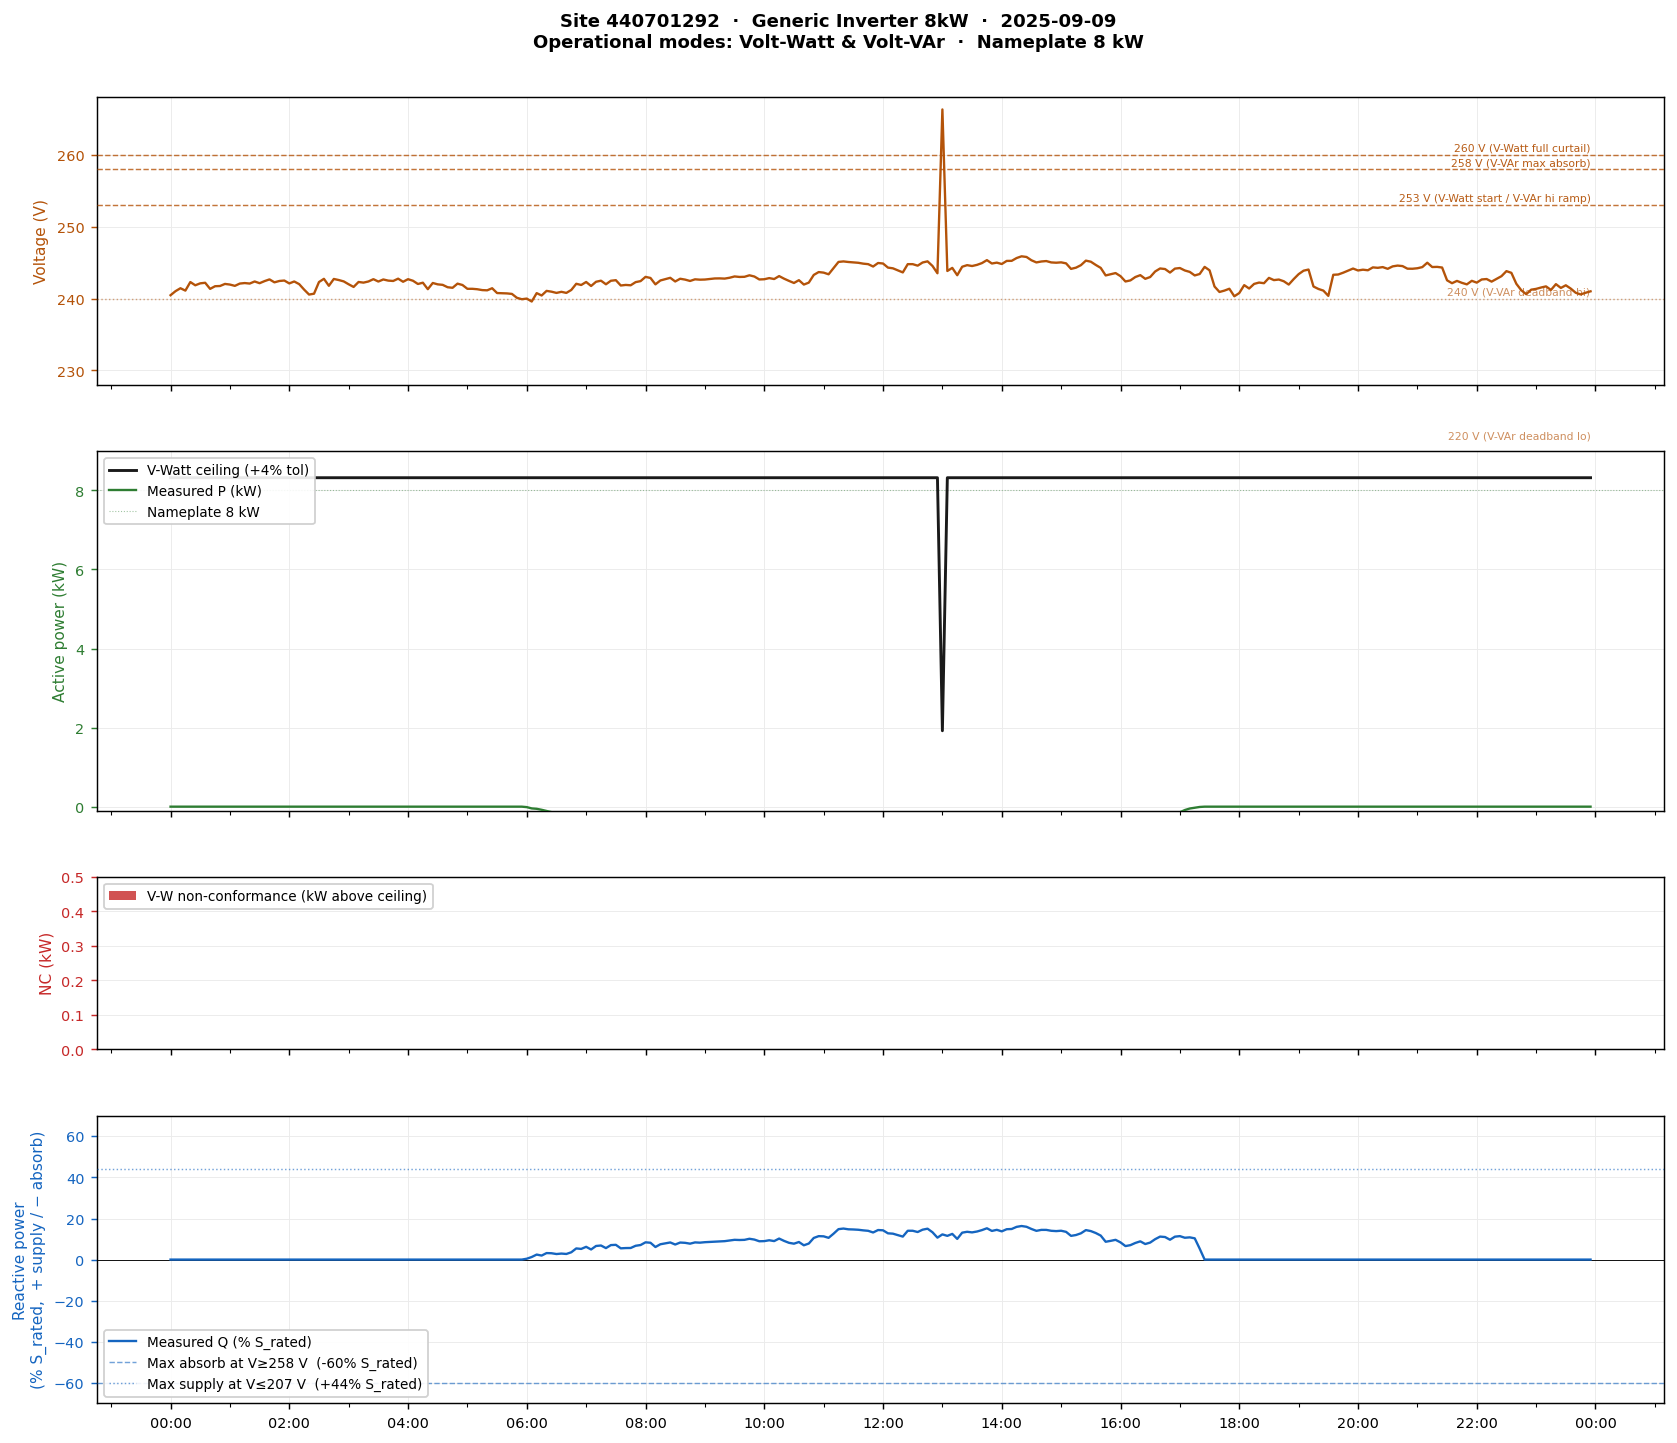

In [ ]:
# =============================================================================
# Pick a day and plot
# =============================================================================
# OPTION A: let the notebook auto-pick the best high-voltage day:
#   Leave OVERRIDE_DATE = None.
#   When PLOT_MONTH is None (full-year mode) it picks the day with the most
#   high-voltage intervals from the smart day picker above.
#   When PLOT_MONTH is set it defaults to the 7th of that month.
#
# OPTION B: name a specific date:
#   Set OVERRIDE_DATE = "YYYY-MM-DD" (string).
#   This bypasses auto-selection entirely.
#
# PLOT_TYPE is inherited from the config cell ("operational" or "protective").
# You can override it here for a one-off.
# =============================================================================

import matplotlib.pyplot as plt

OVERRIDE_DATE = None          # e.g. "2024-01-07" __ set this to pin a date

if OVERRIDE_DATE is not None:
    # Option B: explicit date
    zoom_date = OVERRIDE_DATE
    print(f"Using manually specified date: {zoom_date}")

elif PLOT_MONTH is None:
    # Option A, full-year mode: auto-pick from days_with_events
    if not days_with_events.empty:
        _best_date = days_with_events.index[0]      # datetime.date of top day for high voltage events
        zoom_date  = str(_best_date)
    else:
        zoom_date = f"{PLOT_YEAR}-01-01"
    print(f"PLOT_MONTH is None (full-year mode). Auto-selected zoom_date: {zoom_date}")

else:
    # Option A, single-month mode: default to 7th of that month
    zoom_date = f"{PLOT_YEAR}-{PLOT_MONTH:02d}-07"  # 7th day hardcoded for single-month mode
    print(f"Using default day-of-month: {zoom_date}")

# filter to the chosen day
mask   = df["t_stamp_aest"].dt.date == pd.Timestamp(zoom_date).date()
df_day = df[mask].copy()

if df_day.empty:
    print(f"No data for {zoom_date}.")
    print("Dates with data:", sorted(df["t_stamp_aest"].dt.date.unique())[:10])
else:
    # Derive Q_kvar if not already present
    # (energy_reactive is var·h per 5-min interval; ×12 converts to kvar)
    if "Q_kvar" not in df_day.columns and "energy_reactive" in df_day.columns:
        df_day["Q_kvar"] = df_day["energy_reactive"] / 1000 * 12

    plot_kwargs = dict(
        df_day         = df_day,
        site_id        = chosen_site_id,
        ac_capacity_kw = chosen_cap,
        zoom_date      = zoom_date,
        as4777         = AS4777,
        manufacturer   = chosen_mfr,
    )
    if PLOT_TYPE == "operational":
        plot_operational(**plot_kwargs)
    elif PLOT_TYPE == "protective":
        plot_protective(**plot_kwargs)
    else:
        print(f"Unknown PLOT_TYPE '{PLOT_TYPE}'. Use 'operational' or 'protective'.")

Plotting V-VAr time series for: 2025-09-09


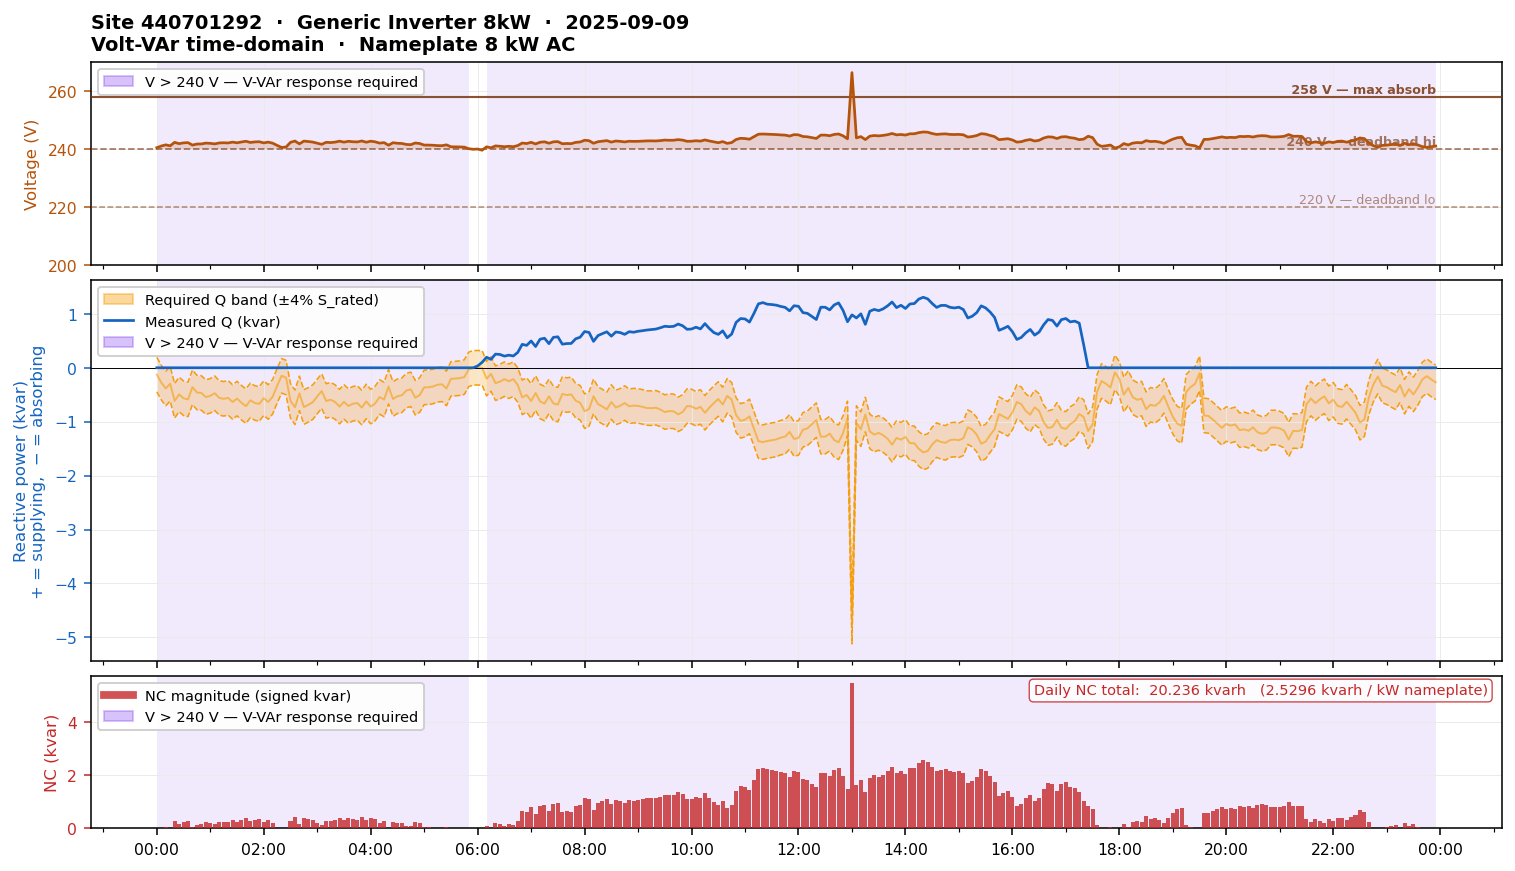

Daily V-VAr NC:  20.236 kvarh  (2.5296 kvarh/kW nameplate)  across 259 non-conforming intervals


In [167]:
# ── 3.3b  Volt-VAr time-domain: Q vs time with NC bars ──────────────────────
# conformance_voltvar is a daily aggregate table — it has no per-interval
# voltage or Q columns. We reconstruct the required Q band from the raw
# telemetry already in df, using the AS4777 V-VAr setpoints directly.
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.patches import Patch

vv  = AS4777["VVAR"]
tol = AS4777["TOL_FRAC"]

def _vvar_required(v, s):
    """Return required Q (kvar) at voltage v for nameplate s (kW).
    AS/NZS 4777.2:2020 Region A piecewise linear curve.
    Sign: + = supplying (lagging), − = absorbing (leading).
    """
    if v <= vv["V1"]:
        return  vv["Q1"] * s
    elif v <= vv["V2"]:
        return  vv["Q1"] * s * (vv["V2"] - v) / (vv["V2"] - vv["V1"])
    elif v <= vv["V3"]:
        return 0.0
    elif v <= vv["V4"]:
        return -vv["Q4"] * s * (v - vv["V3"]) / (vv["V4"] - vv["V3"])
    else:
        return -vv["Q4"] * s

# ── select the day ────────────────────────────────────────────────────────────
if "zoom_date" in dir() and zoom_date:
    _vv_date           = pd.Timestamp(zoom_date).date()
    VV_ZOOM_DATE_START = str(_vv_date)
else:
    VV_ZOOM_DATE_START = f"{PLOT_YEAR}-01-08"

print(f"Plotting V-VAr time series for: {VV_ZOOM_DATE_START}")

mask = df["t_stamp_aest"].dt.date == pd.Timestamp(VV_ZOOM_DATE_START).date()
day  = df[mask].copy()

if day.empty:
    print(f"No data for {VV_ZOOM_DATE_START}.")
    print("Available dates:", sorted(df["t_stamp_aest"].dt.date.unique())[:10])
else:
    # ── derive required Q band ────────────────────────────────────────────
    day["Q_req"]     = day["voltage"].map(lambda v: _vvar_required(v, chosen_cap))
    day["Q_req_max"] = day["Q_req"] + tol * chosen_cap
    day["Q_req_min"] = day["Q_req"] - tol * chosen_cap

    # ── non-conformance ───────────────────────────────────────────────────
    day["nc_vvar"] = (
        np.maximum(0, day["Q_kvar"] - day["Q_req_max"]) +
        np.maximum(0, day["Q_req_min"] - day["Q_kvar"])
    )
    day["nc_signed"] = np.where(
        day["Q_kvar"] > day["Q_req_max"],
         day["Q_kvar"] - day["Q_req_max"],
        np.where(
            day["Q_kvar"] < day["Q_req_min"],
            -(day["Q_req_min"] - day["Q_kvar"]),
            0.0
        )
    )

    # ── daily NC summary ──────────────────────────────────────────────────
    # Each interval is 5 minutes = 5/60 hours.
    # nc_vvar is in kvar; multiplying by interval hours gives kvarh.
    INTERVAL_H = 5 / 60
    nc_kvarh       = day["nc_vvar"].sum() * INTERVAL_H
    nc_kvarh_per_kw = nc_kvarh / chosen_cap   # normalised by nameplate

    # ── zone flags ────────────────────────────────────────────────────────
    vv_active = day["voltage"] > vv["V3"]

    t_plot = day["t_stamp_aest"].dt.tz_localize(None)

    C_V     = "#b45309"
    C_Q     = "#1565c0"
    C_REF   = "#f59e0b"
    C_NC    = "#c62828"
    C_SHADE = "#7c3aed"
    C_GRID  = "#ebebeb"

    fig = plt.figure(figsize=(12, 7.5), dpi=140)
    fig.subplots_adjust(left=0.13, right=0.97, top=0.93, bottom=0.07)
    gs    = fig.add_gridspec(3, 1, height_ratios=[1.6, 3, 1.2], hspace=0.06)
    ax_v  = fig.add_subplot(gs[0])
    ax_q  = fig.add_subplot(gs[1], sharex=ax_v)
    ax_nc = fig.add_subplot(gs[2], sharex=ax_v)

    # ── zone shading ──────────────────────────────────────────────────────
    for _ax in (ax_v, ax_q, ax_nc):
        _ax.fill_between(t_plot, 0, 1,
                         where=vv_active.values,
                         transform=_ax.get_xaxis_transform(),
                         color=C_SHADE, alpha=0.10, linewidth=0, zorder=0)

    _shade_patch = Patch(color=C_SHADE, alpha=0.30,
                         label=f"V > {vv['V3']:.0f} V — V-VAr response required")

    # ═══ PANEL 1 — Voltage ═══════════════════════════════════════════════
    ax_v.plot(t_plot, day["voltage"], color=C_V, lw=1.4, zorder=4)
    ax_v.fill_between(t_plot, vv["V3"], day["voltage"],
                      where=day["voltage"].values >= vv["V3"],
                      color=C_V, alpha=0.18, linewidth=0, zorder=2)
    for vref, ls, lw_, al, fw, lbl in [
        (vv["V2"], "--", 0.8, 0.55, "normal", f"{vv['V2']:.0f} V — deadband lo"),
        (vv["V3"], "--", 0.9, 0.65, "bold",   f"{vv['V3']:.0f} V — deadband hi"),
        (vv["V4"], "-",  1.1, 0.85, "bold",   f"{vv['V4']:.0f} V — max absorb"),
    ]:
        ax_v.axhline(vref, color="#78350f", lw=lw_, ls=ls, alpha=al, zorder=3)
        ax_v.text(t_plot.iloc[-1], vref + 0.3, f" {lbl}",
                  va="bottom", ha="right", fontsize=6.5,
                  fontweight=fw, color="#78350f", alpha=al)
    ax_v.set_ylabel("Voltage (V)", fontsize=8.5, color=C_V)
    ax_v.tick_params(axis="y", colors=C_V, labelsize=8, labelbottom=False)
    ax_v.set_ylim(200, 270)
    ax_v.grid(True, color=C_GRID, lw=0.5, zorder=0)
    ax_v.set_facecolor("white")
    ax_v.legend(handles=[_shade_patch], fontsize=7.5,
                loc="upper left", framealpha=0.92, edgecolor="#cccccc")

    # ═══ PANEL 2 — Reactive power vs required band ════════════════════════
    ax_q.fill_between(t_plot, day["Q_req_min"], day["Q_req_max"],
                      color=C_REF, alpha=0.25, linewidth=0, zorder=1)
    ax_q.plot(t_plot, day["Q_req_min"], color=C_REF, lw=0.8, ls="--", zorder=2)
    ax_q.plot(t_plot, day["Q_req_max"], color=C_REF, lw=0.8, ls="--", zorder=2)
    ax_q.plot(t_plot, day["Q_req"],     color=C_REF, lw=1.0, ls="-",  zorder=2, alpha=0.6)
    ax_q.plot(t_plot, day["Q_kvar"],    color=C_Q,   lw=1.4, zorder=4)
    ax_q.axhline(0, color="k", lw=0.5, zorder=3)
    ax_q.set_ylabel("Reactive power (kvar)\n+ = supplying,  − = absorbing",
                    fontsize=8.5, color=C_Q)
    ax_q.tick_params(axis="y", colors=C_Q, labelsize=8, labelbottom=False)
    ax_q.grid(True, color=C_GRID, lw=0.5, zorder=0)
    ax_q.set_facecolor("white")
    ax_q.legend(handles=[
        Patch(color=C_REF, alpha=0.40, label=f"Required Q band (±{tol*100:.0f}% S_rated)"),
        plt.Line2D([0], [0], color=C_Q,  lw=1.4, label="Measured Q (kvar)"),
        _shade_patch,
    ], fontsize=7.5, loc="upper left", framealpha=0.92, edgecolor="#cccccc")

    # ═══ PANEL 3 — Non-conformance (signed) + daily summary ══════════════
    ax_nc.bar(t_plot, day["nc_signed"],
              width=pd.Timedelta(minutes=4.5),
              color=C_NC, alpha=0.80, align="center", zorder=3)
    ax_nc.axhline(0, color="k", lw=0.5, zorder=3)
    ax_nc.set_ylabel("NC (kvar)", fontsize=8.5, color=C_NC)
    ax_nc.tick_params(axis="y", colors=C_NC, labelsize=8)
    ax_nc.grid(True, color=C_GRID, lw=0.5, axis="y", zorder=0)
    ax_nc.set_facecolor("white")

    # Daily NC summary annotation
    # kvarh = total reactive energy non-conformant across the day
    # kvarh/kW = normalised by nameplate (site-size independent)
    ax_nc.legend(handles=[
        plt.Line2D([0], [0], color=C_NC, lw=4, alpha=0.80,
                   label=f"NC magnitude (signed kvar)"),
        _shade_patch,
    ], fontsize=7.5, loc="upper left", framealpha=0.92, edgecolor="#cccccc")
    ax_nc.text(0.99, 0.95,
               f"Daily NC total:  {nc_kvarh:.3f} kvarh"
               f"   ({nc_kvarh_per_kw:.4f} kvarh / kW nameplate)",
               transform=ax_nc.transAxes, ha="right", va="top",
               fontsize=7.5, color=C_NC,
               bbox=dict(boxstyle="round,pad=0.3", fc="white",
                         ec=C_NC, alpha=0.85, lw=0.7))

    ax_nc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_nc.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax_nc.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    ax_nc.tick_params(axis="x", which="major", labelsize=8)
    fig.autofmt_xdate(rotation=0, ha="center")

    ax_v.set_title(
        f"Site {chosen_site_id}  ·  {chosen_mfr}  ·  {VV_ZOOM_DATE_START}\n"
        f"Volt-VAr time-domain  ·  Nameplate {chosen_cap:.0f} kW AC",
        fontsize=10, fontweight="bold", pad=6, loc="left")
    plt.show()

    print(f"Daily V-VAr NC:  {nc_kvarh:.3f} kvarh  "
          f"({nc_kvarh_per_kw:.4f} kvarh/kW nameplate)  "
          f"across {int(day['nc_vvar'].gt(0).sum())} non-conforming intervals")

Pulling V-VAr scatter data for site 440701292, 2025-02 ...
Pulled 8,036 intervals.


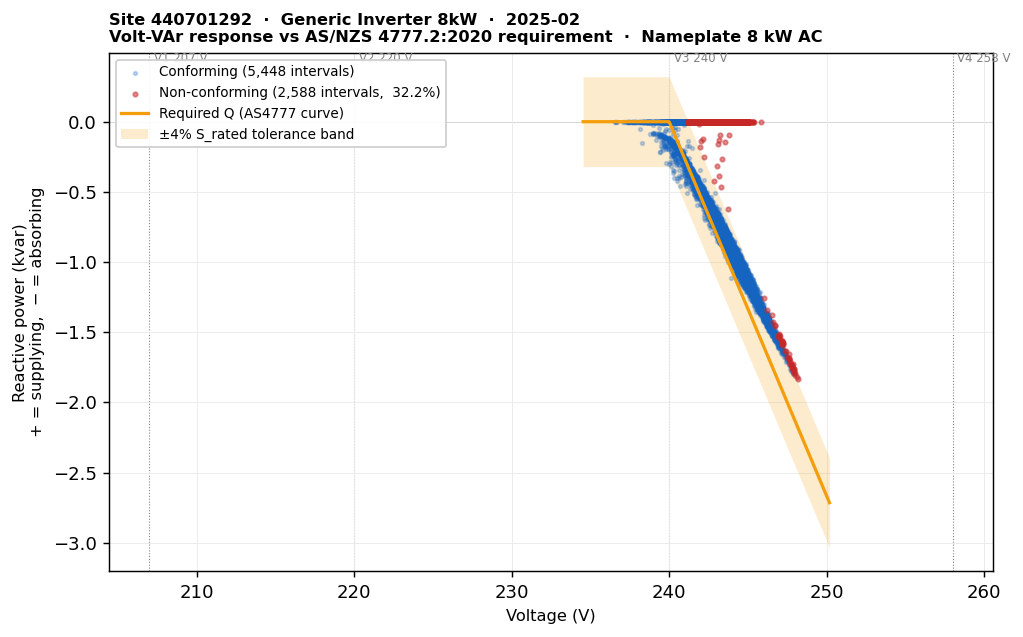

Non-conforming intervals: 2,588 / 8,036  (32.2%)


In [168]:
# ── 3.3c  Volt-VAr monthly scatter: Q vs V for one site-month ────────────────
# Each dot is one 5-minute interval. The required Q curve and ±4% tolerance
# band are overlaid so you can see at a glance how well the inverter tracks
# the standard across the full voltage distribution for the month.
#
# Requires: chosen_site_id, chosen_cap, chosen_mfr, PLOT_YEAR, PLOT_MONTH,
#           AS4777, SAI, aq() — all set in the site-picker cell.
# If PLOT_MONTH is None (full-year pull), defaults to month 2 as a fallback.
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

vv  = AS4777["VVAR"]
tol = AS4777["TOL_FRAC"]

# ── month to plot ─────────────────────────────────────────────────────────────
_scatter_month = PLOT_MONTH if PLOT_MONTH is not None else 2
_month_clause  = f"AND month = {_scatter_month}"
_period_label  = f"{PLOT_YEAR}-{_scatter_month:02d}"

print(f"Pulling V-VAr scatter data for site {chosen_site_id}, {_period_label} ...")

# ── pull per-interval site-level aggregates from ts ──────────────────────────
# We aggregate across all PV circuits at the site (sum power/energy, avg voltage)
# so the grain is (site, timestamp) rather than (circuit, timestamp).
# circuit_polarity weights the sign correctly for multi-circuit sites.
scatter_df = aq(f"""
    WITH site_agg AS (
        SELECT
            t_stamp,
            sum(power   * circuit_polarity / 1000)       AS P_kW,
            sum(energy_reactive * circuit_polarity
                / 1000 * 12)                             AS Q_kvar,
            avg(voltage)                                 AS V
        FROM ts
        JOIN (
            SELECT DISTINCT circuit_id, circuit_polarity
            FROM meta_up23c
            WHERE is_pv    = True
              AND site_id  = {chosen_site_id}
        ) m USING (circuit_id)
        WHERE year    = {PLOT_YEAR}
          {_month_clause}
          AND is_pv   = True
          AND voltage > 0
          AND voltage < 300
        GROUP BY t_stamp
    )
    SELECT t_stamp, P_kW, Q_kvar, V
    FROM site_agg
    ORDER BY t_stamp
""", database=SAI)

print(f"Pulled {len(scatter_df):,} intervals.")

if scatter_df.empty:
    print("No data returned. Check site_id, year, and month.")
else:
    # ── required Q curve over the observed voltage range ──────────────────
    V_grid    = np.linspace(scatter_df["V"].min() - 2,
                            scatter_df["V"].max() + 2, 500)
    Q_req     = np.array([_vvar_required(v, chosen_cap) for v in V_grid])
    Q_req_max = Q_req + tol * chosen_cap
    Q_req_min = Q_req - tol * chosen_cap

    # ── conformance flag per interval ─────────────────────────────────────
    scatter_df["Q_req"] = scatter_df["V"].map(
        lambda v: _vvar_required(v, chosen_cap))
    scatter_df["Q_req_max"] = scatter_df["Q_req"] + tol * chosen_cap
    scatter_df["Q_req_min"] = scatter_df["Q_req"] - tol * chosen_cap
    scatter_df["nc"] = (
        (scatter_df["Q_kvar"] > scatter_df["Q_req_max"]) |
        (scatter_df["Q_kvar"] < scatter_df["Q_req_min"])
    )

    n_total = len(scatter_df)
    n_nc    = scatter_df["nc"].sum()
    pct_nc  = 100 * n_nc / n_total if n_total > 0 else 0.0

    # ── colours ──────────────────────────────────────────────────────────
    C_OK  = "#1565c0"   # blue   — conforming intervals
    C_NC  = "#c62828"   # red    — non-conforming intervals
    C_REF = "#f59e0b"   # amber  — required band

    fig, ax = plt.subplots(figsize=(8, 5), dpi=130)

    # conforming and non-conforming points plotted separately for legend clarity
    ok_mask = ~scatter_df["nc"]
    ax.scatter(scatter_df.loc[ok_mask,  "V"],
               scatter_df.loc[ok_mask,  "Q_kvar"],
               s=4, alpha=0.25, color=C_OK, zorder=3,
               label=f"Conforming ({ok_mask.sum():,} intervals)")
    ax.scatter(scatter_df.loc[~ok_mask, "V"],
               scatter_df.loc[~ok_mask, "Q_kvar"],
               s=6, alpha=0.50, color=C_NC, zorder=4,
               label=f"Non-conforming ({n_nc:,} intervals,  {pct_nc:.1f}%)")

    # required Q curve and band
    ax.plot(V_grid, Q_req, color=C_REF, lw=1.8, zorder=5,
            label="Required Q (AS4777 curve)")
    ax.fill_between(V_grid, Q_req_min, Q_req_max,
                    color=C_REF, alpha=0.20, linewidth=0, zorder=2,
                    label=f"±{tol*100:.0f}% S_rated tolerance band")

    # voltage setpoint reference lines
    ax.axhline(0, color="k", lw=0.5, zorder=1)
    for vx, lbl in [
        (vv["V1"], f"V1 {vv['V1']:.0f} V"),
        (vv["V2"], f"V2 {vv['V2']:.0f} V"),
        (vv["V3"], f"V3 {vv['V3']:.0f} V"),
        (vv["V4"], f"V4 {vv['V4']:.0f} V"),
    ]:
        ax.axvline(vx, color="grey", lw=0.6, ls=":", zorder=1)
        ax.text(vx + 0.3, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0
                else chosen_cap * vv["Q1"] * 1.05,
                lbl, fontsize=6.5, color="grey", va="top")

    ax.set_xlabel("Voltage (V)", fontsize=9)
    ax.set_ylabel("Reactive power (kvar)\n+ = supplying,  − = absorbing", fontsize=9)
    ax.set_title(
        f"Site {chosen_site_id}  ·  {chosen_mfr}  ·  {_period_label}\n"
        f"Volt-VAr response vs AS/NZS 4777.2:2020 requirement  ·  "
        f"Nameplate {chosen_cap:.0f} kW AC",
        fontsize=9, fontweight="bold", loc="left")
    ax.legend(fontsize=7.5, loc="upper left", framealpha=0.92, edgecolor="#cccccc")
    ax.grid(color="#ebebeb", lw=0.5)
    ax.set_facecolor("white")
    plt.tight_layout()
    plt.show()

    print(f"Non-conforming intervals: {n_nc:,} / {n_total:,}  ({pct_nc:.1f}%)")